## Example for on-the-fly refinement

In [1]:
import numpy as np
import pickle  # if you want to load data from `data` directory rather than repeating SimpleMD runs
import copy  # required to copy dictionaries without modifying the original ones
import matplotlib.pyplot as plt

In [2]:
from simpleMD import generate_chain, SimpleMD

### 1. MD simulation for the prior model

In [3]:
cell = (100., 100., 100.)
positions = generate_chain(10, 1.)

In [4]:
keys_prior = {
 'temperature' : 0.722,
 'tstep' : 0.001,
 'friction' : 1.0,
 'forcecutoff' : 2.5,
 'k_fene' : 30.0,
 'maxbond' : 1.5,
 'q_SAXS' : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
 'listcutoff' : 3.0,
 'nstep' : int(1e5),
 'nconfig' : 1000,
 'nstat' : 100,
 'nequilib' : int(1e4)
 }

# generate a crystal lattice and pass it:
keys_prior["cell"] = cell
keys_prior["positions"] = positions

In [5]:
# create runner
smd_prior = SimpleMD(**keys_prior)

# run
smd_prior.run()

100%|██████████| 100000/100000 [03:40<00:00, 453.82it/s]

fm_SAXS:  [1. 0.]
l_SAXS:  0.0


In [6]:
vars(smd_prior).keys()

dict_keys(['iv', 'iy', 'iset', 'gset', 'write_positions_first', 'write_statistics_first', 'write_statistics_last_time_reopened', 'write_statistics_fp', 'temperature', 'maxneighbors', 'tstep', 'friction', 'forcecutoff', 'k_fene', 'maxbond', 'k_angle', 'l_rgyr2', 'exp_rgyr2', 'k_rgyr2', 'tau_rgyr2', 'alpha_rgyr2', 'sigma_rgyr2', 'q_SAXS', 'l_SAXS', 'a_SAXS', 'b_SAXS', 'c_SAXS', 'exp_SAXS', 'k_SAXS', 'tau_SAXS', 'alpha', 'beta', 'gamma', 'sigma_SAXS', 'k_fm', 'tau_fm', 'eta_ff0', 'tau_ff', 'listcutoff', 'nstep', 'nconfig', 'nstat', 'nequilib', 'nonthefly', 'nupdate', 'idum', 'wrapatoms', 'statfile', 'trajfile', 'outputfile', 'inputfile', 'positions', 'cell', 'statfile_f', 'statistics', 'lambda_otf', 'SAXS_otf', 'fm_otf', 'trajectory', 'SAXS', 'grad_lambda', 'angle', 'output'])

### 2. MD simulation for the test (reference) model

In [7]:
keys_test = copy.deepcopy(keys_prior)  # required to not modify keys_prior

keys_test.update({
    'k_angle' : 5.0,
    'nstat' : 10,
    'nconfig' : 100
    })

In [8]:
# create runner
smd_test = SimpleMD(**keys_test)

# run
smd_test.run()

100%|██████████| 100000/100000 [05:03<00:00, 328.99it/s]

fm_SAXS:  [1. 0.]
l_SAXS:  0.0


### 3. plots for prior and reference model
- SAXS intensities $I(q)$
- angle distribution $P(\psi)$

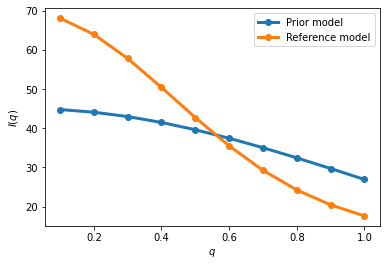

In [9]:
plt.plot(smd_prior.q_SAXS, smd_prior.SAXS, 'o-', label='Prior model', linewidth=3)
plt.plot(smd_test.q_SAXS, 1.5*smd_test.SAXS + 2.0, 'o-', label='Reference model', linewidth=3)
plt.legend()
plt.xlabel(r'$q$')
plt.ylabel(r'$I(q)$')
plt.show()

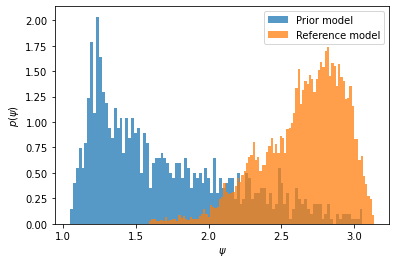

In [10]:
plt.hist(smd_prior.angle[5], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_test.angle[5], bins=100, density=True, alpha=0.75, label='Reference model')
plt.legend()
plt.xlabel(r'$\psi$')
plt.ylabel(r'$p(\psi)$')
plt.show()

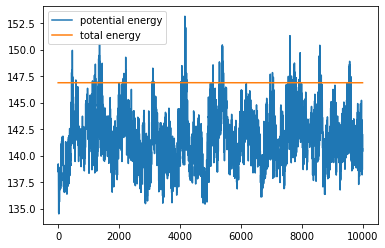

In [11]:
plt.plot(np.array(smd_test.statistics).T[3], label="potential energy")
plt.plot(np.array(smd_test.statistics).T[5], label="total energy")
plt.legend()
plt.show()

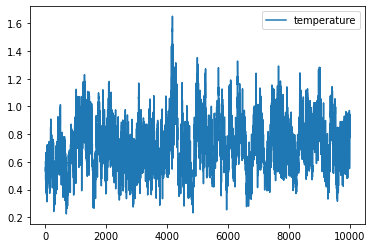

In [12]:
plt.plot(np.array(smd_test.statistics).T[2], label="temperature")
plt.legend()
plt.show()

### 4. posterior model

In [13]:
keys_posterior = copy.deepcopy(keys_prior)

keys_posterior.update({
    'nstep' : 310000,
    'l_rgyr2': 0.0,
    'exp_SAXS': 1.5*smd_test.SAXS + 2.0,
    'k_SAXS': 0.2,
    'tau_SAXS': 5000.0,
    'sigma_SAXS': [1.0],
    'k_fm': [0.1, 0.02],
    'tau_fm': 5000.0,
    'nonthefly' : int(2e5)
    })

In [ ]:
# create runner
smd_posterior = SimpleMD(**keys_posterior)

# run
smd_posterior.run()

 49%|████▉     | 152983/310000 [06:19<11:52, 220.47it/s]

### 5. final plots

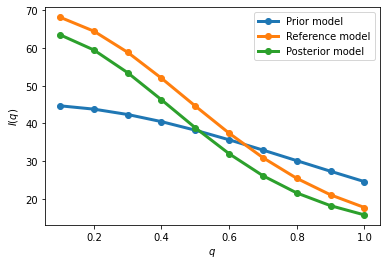

In [ ]:
plt.plot(smd_prior.q_SAXS, smd_prior.SAXS, '-o', label='Prior model',linewidth=3)
plt.plot(smd_posterior.q_SAXS, smd_posterior.exp_SAXS, '-o', label='Reference model',linewidth=3)
plt.plot(smd_posterior.q_SAXS, smd_posterior.SAXS, '-o', label='Posterior model',linewidth=3)
plt.legend()
plt.xlabel(r'$q$')
plt.ylabel(r'$I(q)$')


# plt.savefig('SAXSlfinal.pdf', format='pdf', bbox_inches='tight')

plt.show()

ndata (data collection phase):  7000


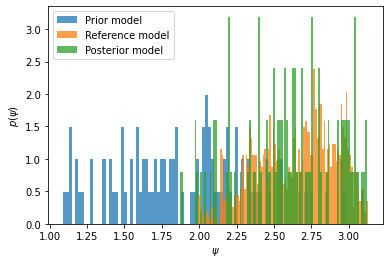

In [ ]:
ndata = smd_posterior.nstep - smd_posterior.nonthefly - smd_posterior.nequilib  # data collection phase
print('ndata (data collection phase): ', ndata)

until = -ndata//smd_posterior.nstat

plt.hist(smd_prior.angle[3], bins=100, density=True, alpha=0.75, label='Prior model')
plt.hist(smd_test.angle[3], bins=100, density=True, alpha=0.75, label='Reference model')
plt.hist(smd_posterior.angle[3][-ndata:], bins=100, density=True, alpha=0.75, label='Posterior model')
plt.xlabel(r'$\psi$')
plt.ylabel(r'$p(\psi)$')
plt.legend()


plt.show()

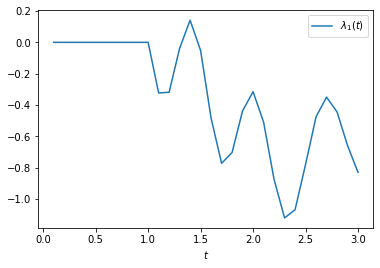

In [ ]:
t = np.array(smd_posterior.statistics).T[1][:until]
lambdas = smd_posterior.lambda_otf[0][:until]

plt.plot(t, lambdas, label=r"$\lambda_1(t)$")
plt.legend()
plt.xlabel(r'$t$')   
plt.savefig('lfinal.pdf', format='pdf', bbox_inches='tight')
plt.show()


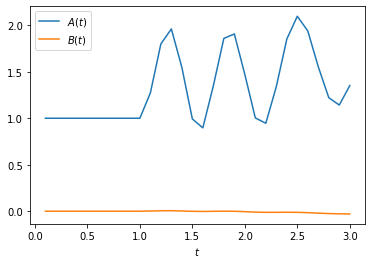

In [ ]:
fm_A = smd_posterior.fm_otf[0][:until]
fm_B = smd_posterior.fm_otf[1][:until]

plt.plot(t, fm_A, label=r'$A(t)$')
plt.plot(t, fm_B, label=r'$B(t)$')
plt.legend()
plt.xlabel(r'$t$')
plt.show()


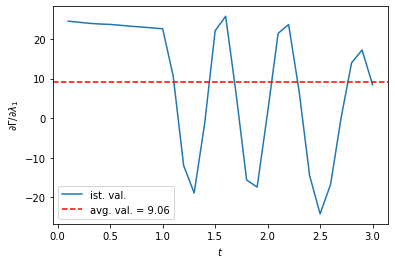

In [ ]:
grad = smd_posterior.grad_lambda[1][:until]

plt.plot(t, grad, label="ist. val.")

avg = np.mean(grad)

plt.axhline(y=avg, color="r", linestyle="--", label=f"avg. val. = {avg:.2f}")
plt.legend()
plt.xlabel(r'$t$')
plt.ylabel(r'$\partial \Gamma /\partial \lambda_1$') 
plt.show()